In [1]:
import pypsa
import numpy as np
import pandas as pd
from pathlib import Path

n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00.nc'
)
m = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00_50.nc'
)

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00_50.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [42]:
opex = n.statistics.opex(groupby='bus')
opex.index = opex.index.get_level_values(1)
opex = opex.groupby(opex.index.str[:2]).sum()
capex = n.statistics.capex(groupby='bus')
capex.index = capex.index.get_level_values(1)
capex = capex.groupby(capex.index.str[:2]).sum()

opex = opex.loc[capex.index]

cc = pd.concat([opex.rename('opex'), capex.rename('capex')], axis=1)
cc['total'] = cc.sum(axis=1)
cc.sort_values('total', ascending=False, inplace=True)

cc.drop('EU', inplace=True)

In [45]:
opex_hike = m.statistics.opex(groupby='bus')
opex_hike.index = opex_hike.index.get_level_values(1)
opex_hike = opex_hike.groupby(opex_hike.index.str[:2]).sum()
capex_hike = m.statistics.capex(groupby='bus')
capex_hike.index = capex_hike.index.get_level_values(1)
capex_hike = capex_hike.groupby(capex_hike.index.str[:2]).sum()

opex_hike = opex_hike.loc[capex_hike.index]

cc_hike = pd.concat([opex_hike.rename('opex'), capex_hike.rename('capex')], axis=1)
cc_hike['total'] = cc_hike.sum(axis=1)
cc_hike.sort_values('total', ascending=False, inplace=True)

cc_hike.drop('EU', inplace=True)

In [46]:
diff = (cc_hike - cc).loc[cc.index]

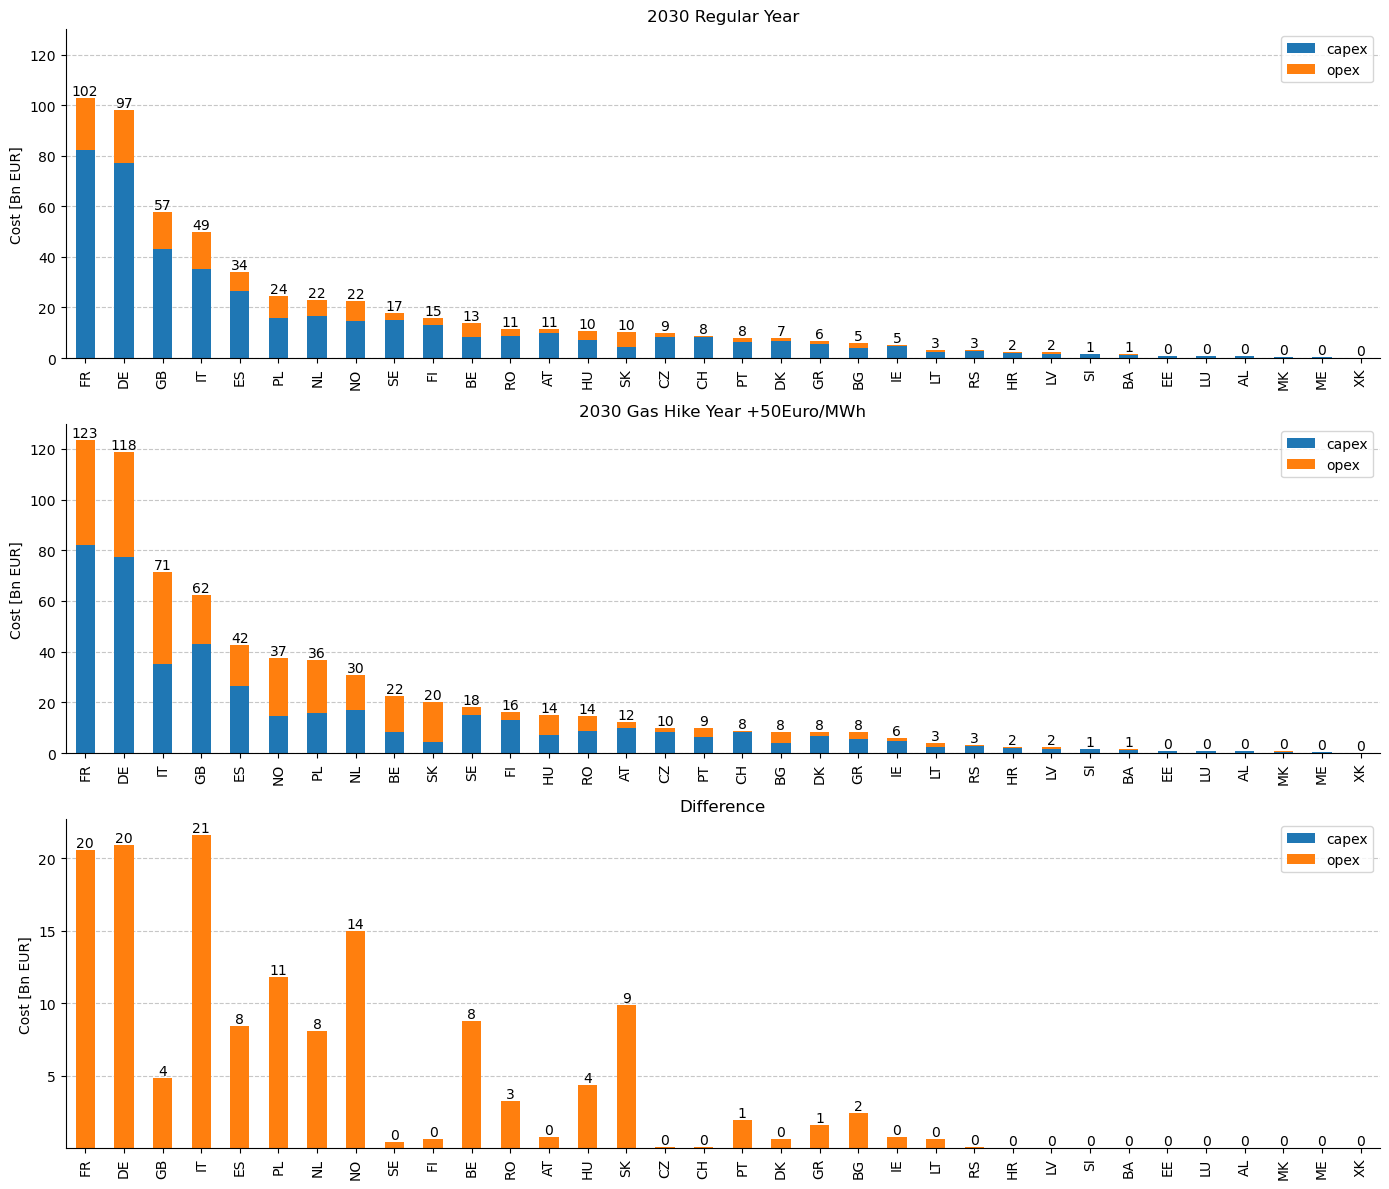

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot cc (original costs)
cc[['capex', 'opex']].mul(1e-9).plot(kind='bar', stacked=True, ax=axes[0], title='2030 Regular Year')
for i, (idx, row) in enumerate(cc.iterrows()):
    axes[0].text(i, row['total']/1e9, f"{int(row['total']/1e9)}", ha='center', va='bottom')

# Plot cc_hike (costs with hike)
cc_hike[['capex', 'opex']].mul(1e-9).plot(kind='bar', stacked=True, ax=axes[1], title='2030 Gas Hike Year +50Euro/MWh')
for i, (idx, row) in enumerate(cc_hike.iterrows()):
    axes[1].text(i, row['total']/1e9, f"{int(row['total']/1e9)}", ha='center', va='bottom')

# Plot diff (difference)
diff[['capex', 'opex']].mul(1e-9).plot(kind='bar', stacked=True, ax=axes[2], title='Difference')
for i, (idx, row) in enumerate(diff.iterrows()):
    axes[2].text(i, row['total']/1e9, f"{int(row['total']/1e9)}", ha='center', va='bottom')

for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('Cost [Bn EUR]')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.7, axis='y')
    ax.set_axisbelow(True)

axes[0].set_ylim(0, 130)

plt.tight_layout()
plt.show()

In [ ]:
n.